# Sentinel-2 Imagery: Dataset Creation & Preprocessing from Raw Data

## Overview
This notebook illustrates the pipeline for extracting and preprocessing perfectly aligned 512x512 image patches from raw Sentinel-2 L1C products. We process pairs of satellite images acquired over the same geographical location during different seasons (Summer vs. Winter) to train a Deep Learning matching model.

The input data consists of original Sentinel-2 product folders (e.g., `S2A_MSIL1C...`) containing JPEG 2000 (`.jp2`) files within the `IMG_DATA` subdirectory.

## Technical Challenges Addressed
1. **Satellite Data Formats:** Reading JPEG 2000 (`.jp2`) geometry and 12-bit pixel data, handled via the `rasterio` library.
2. **"No-Data" and Edge Defects:** Satellite swaths often contain black "No-Data" areas at the swaths' boundaries.
3. **Information Density filtering:** Discarding patches lacking structural variance, such as those covered by dense clouds or homogenous snow fields, as they are unsuitable for feature matching.

We address these challenges by implementing a variance-based filtering mechanism and analyzing the statistical differences in seasonal pixel intensity.

In [ ]:
import os
import glob
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
import cv2 

# Setting up visual style for plots
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Directory Setup and Seasonal Selection

We define the source paths to the raw Sentinel-2 products. To simulate the preprocessing pipeline, we manually select a set of summer and winter products that cover the same geographical tile (e.g., tile `T36UYA`).

*Note: For demonstration purposes in this notebook, please ensure at least one pair of raw Summer and Winter Sentinel-2 folders is available in the configured root directory.*

In [ ]:
# Root directory where raw Sentinel-2 products arestored 
RAW_DATA_ROOT = "./"

# Target directories for processed patches (your existing prepared_dataset)
PROCESSED_SUMMER_DIR = "./prepared_dataset/summer"
PROCESSED_WINTER_DIR = "./prepared_dataset/winter"

# conceptual demonstration of seasonal grouping
summer_product_id = "S2A_MSIL1C_20160618T082602_N0204_R021_T36UYA_20160618T083357"
winter_product_id = "S2A_MSIL1C_20161205T083332_N0204_R021_T36UYA_20161205T083327"

# Helper function to get the actual JP2 file path from IMG_DATA
def get_band_path(product_root, band="TCI"):
    """
    Finds the path to the specified spectral band JP2 file.
    Defaulting to TCI (True Color Image) for structural matching.
    """
    img_data_path = os.path.join(product_root, summer_product_id, "IMG_DATA")
    # Search for JP2 file ending with the band designation (e.g., ..._TCI.jp2)
    search_pattern = os.path.join(img_data_path, f"*{band}.jp2")
    files = glob.glob(search_pattern)
    if files:
        return files[0]
    return None

# Placeholder paths for demonstration (need actual data to be non-None)
summer_jp2_path = get_band_path(RAW_DATA_ROOT, band="TCI")
winter_jp2_path = get_band_path(RAW_DATA_ROOT, band="TCI")
print(f"Conceptual Summer JP2 source: {summer_jp2_path}")

Conceptual Summer JP2 source: ./S2A_MSIL1C_20160618T082602_N0204_R021_T36UYA_20160618T083357\IMG_DATA\T36UYA_20160618T082602_TCI.jp2


## 2. Statistical Data Analysis
Before automated cropping, we analyze the pixel intensity distributions of the raw `.jp2` images using `rasterio`. This statistical overview is crucial for defining appropriate thresholds for our filtering algorithms. Winter imagery naturally displays a significant skew towards higher intensity values due to snow cover.

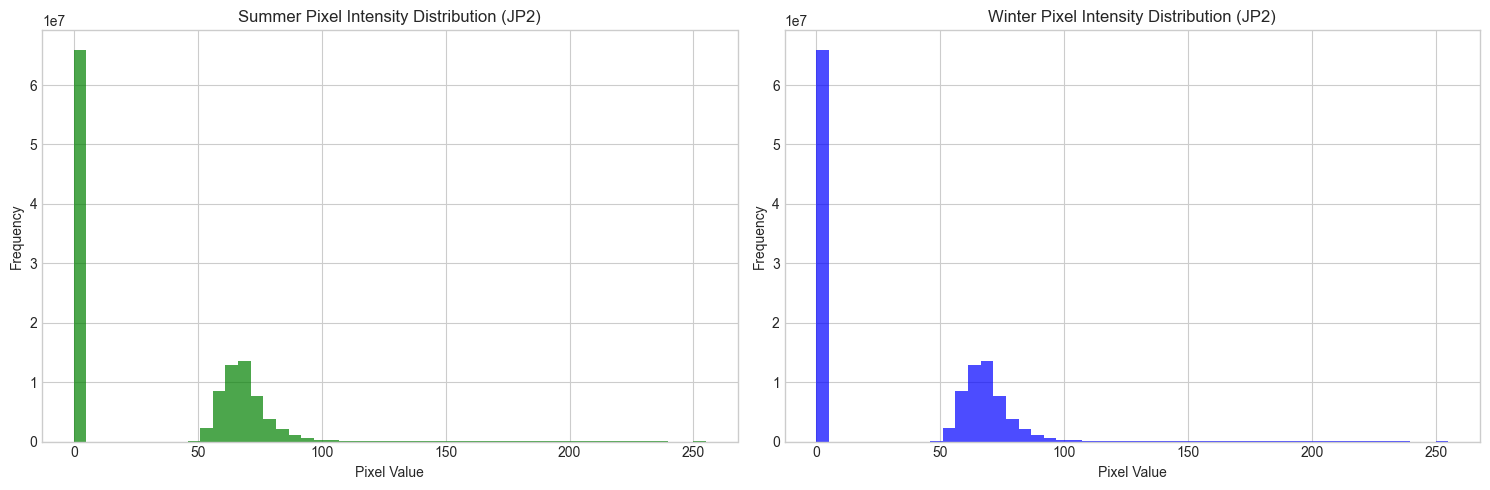

In [ ]:
def plot_jp2_intensity_histograms(summer_img_path, winter_img_path):
    """Visualizes the pixel intensity distribution of raw Sentinel-2 JP2 pairs."""
    try:
        # Read a sample using rasterio
        with rasterio.open(summer_img_path) as src_s, rasterio.open(winter_img_path) as src_w:
            # Sentinel-2 TCI JP2s are often stored as 8-bit, but can be 12-bit.
            # Reading Band 1 as grayscale representation
            summer_arr = src_s.read(1) 
            winter_arr = src_w.read(1)

        plt.figure(figsize=(15, 5))
        
        # Summer Histogram
        plt.subplot(1, 2, 1)
        plt.hist(summer_arr.ravel(), bins=50, color='green', alpha=0.7)
        plt.title("Summer Pixel Intensity Distribution (JP2)")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        # Winter Histogram
        plt.subplot(1, 2, 2)
        plt.hist(winter_arr.ravel(), bins=50, color='blue', alpha=0.7)
        plt.title("Winter Pixel Intensity Distribution (JP2)")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error reading JP2 files for histogram: {e}")

plot_jp2_intensity_histograms(summer_jp2_path, winter_jp2_path)

## 3. Patch Extraction Parameters and Filtering Logic
We define parameters for extracting `512x512` patches and set criteria for information density filtering. Discarding homogenous or empty patches ensures the Deep Learning model is trained on high-signal-to-noise ratio data.

In [4]:
PATCH_SIZE = 512
VARIANCE_THRESHOLD = 150.0  # Threshold to filter homogenous clouds/snow

def is_valid_patch(patch):
    """
    Check if the satellite image patch contains sufficient information density.
    Calculates mean for 'No-Data' detection and variance for feature complexity.
    """
    # Filtering "No-Data" areas (very low intensity)
    if np.mean(patch) < 10:
        return False
    # Filtering features like clouds or uniform snow (very low variance)
    if np.var(patch) < VARIANCE_THRESHOLD:
        return False
    return True

## 4. Quality Assurance: Accepted vs. Discarded
A quick visual check to confirm our variance threshold is working correctly, ensuring only information-rich patches are fed into the neural network.

In [5]:
def show_data_quality_grid(valid_patch, discarded_patch):
    """Displays a side-by-side comparison of a kept vs. rejected patch."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(valid_patch, cmap='gray')
    axes[0].set_title(f"Accepted (High Variance: {np.var(valid_patch):.1f})")
    axes[0].axis('off')
    
    axes[1].imshow(discarded_patch, cmap='gray')
    axes[1].set_title(f"Discarded (Low Variance: {np.var(discarded_patch):.1f})")
    axes[1].axis('off')
    
    plt.show()

## 4. Main Processing Loop: Windowed Patch Extraction
This core algorithm performs the dataset creation. We iterate through the massive `.jp2` imagery using `rasterio.windows.Window` to extract patches without loading the entire image into memory. If both summer and winter patches pass the validation filter, they are saved as PNG files to the ready-to-use dataset directory.

In [ ]:
def process_seasonal_jp2_pairs(summer_jp2_path, winter_jp2_path, filename_base):
    """
    Executes windowed extraction and filtering on a pair of raw JP2 files.
    """
    try:
        with rasterio.open(summer_jp2_path) as src_summer, rasterio.open(winter_jp2_path) as src_winter:
            height = src_summer.height
            width = src_summer.width
            
            # Verify image alignment
            if height != src_winter.height or width != src_winter.width:
                print(f"Error: Seasonal images are not aligned for {filename_base}. Skipping.")
                return

            saved_patches = 0
            discarded_patches = 0
            
            # Iterate through the image using Window
            for y in range(0, height - PATCH_SIZE + 1, PATCH_SIZE):
                for x in range(0, width - PATCH_SIZE + 1, PATCH_SIZE):
                    window = Window(x, y, PATCH_SIZE, PATCH_SIZE)
                    
                    # Read single band (or can be adjusted for 3-band TCI)
                    patch_s = src_summer.read(1, window=window)
                    patch_w = src_winter.read(1, window=window)
                    
                    if is_valid_patch(patch_s) and is_valid_patch(patch_w):
                        # Construct a unique name including base filename and top-left coordinates
                        patch_name = f"{filename_base}_{y}_{x}.png"
                        
                        # Save valid patches as PNG for training
                        cv2.imwrite(os.path.join(PROCESSED_SUMMER_DIR, patch_name), patch_s)
                        cv2.imwrite(os.path.join(PROCESSED_WINTER_DIR, patch_name), patch_w)
                        saved_patches += 1
                    else:
                        discarded_patches += 1
                        
            print(f"Extraction for {filename_base} Complete. Valid Pairs Saved: {saved_patches} | Discarded: {discarded_patches}")

    except Exception as e:
        print(f"Error processing JP2 pair {filename_base}: {e}")


process_seasonal_jp2_pairs(summer_jp2_path, winter_jp2_path, filename_base="tile_T36UYA")

Extraction for tile_T36UYA Complete. Valid Pairs Saved: 87 | Discarded: 354
